In [1]:
import pandas as pd
import seaborn as sns

In [2]:
tips = sns.load_dataset('tips')

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
titanic = pd.read_csv('train.csv')

In [5]:
flights = sns.load_dataset('flights')

In [6]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [7]:
iris = sns.load_dataset('iris')

In [8]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


# 1. Scatterplot (Numerical - Numerical)

<Axes: xlabel='total_bill', ylabel='tip'>

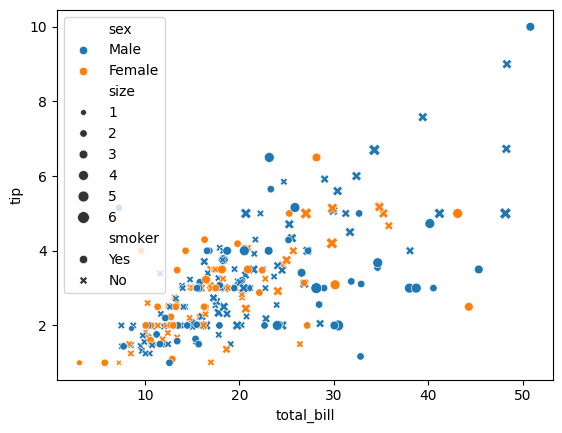

In [11]:
sns.scatterplot(
    x='total_bill',
    y='tip',
    data=tips,
    hue='sex',
    style='smoker',
    size='size'
)

In [12]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 2. Bar Plot (Numerical - Categorical)

<Axes: xlabel='Pclass', ylabel='Age'>

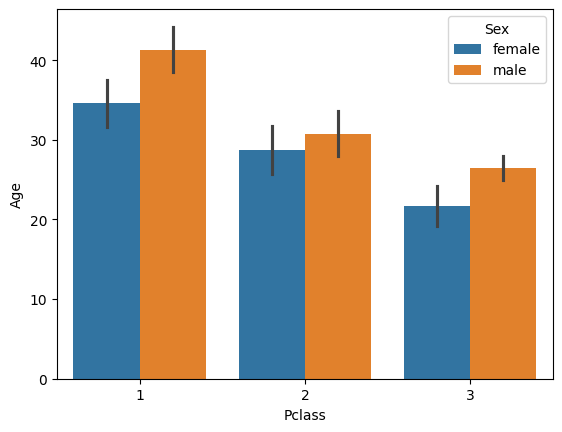

In [13]:
sns.barplot(data=titanic,
            x='Pclass',
            y='Age',
            hue='Sex')

# 3. Box Plot (Numerical - Categorical)

<Axes: xlabel='Sex', ylabel='Age'>

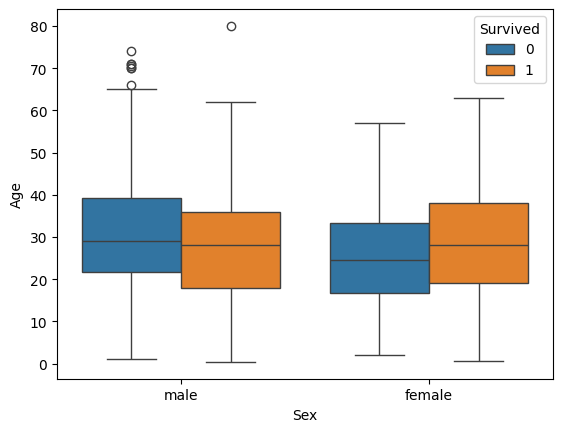

In [14]:
sns.boxplot(data=titanic,
            x='Sex',
            y='Age',
            hue='Survived')

# 4. KDEplot (Numerical - Categorical)

<Axes: xlabel='Age', ylabel='Density'>

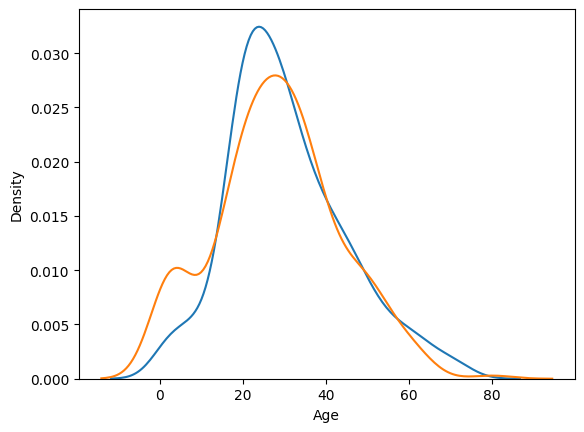

In [17]:
sns.kdeplot(data=titanic[titanic['Survived'] == 0], x='Age', label='Not Survived')
sns.kdeplot(data=titanic[titanic['Survived'] == 1], x='Age', label='Survived')

# 5. HeatMap (Categorical - Categorical)

In [18]:
titanic.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


<Axes: xlabel='Survived', ylabel='Pclass'>

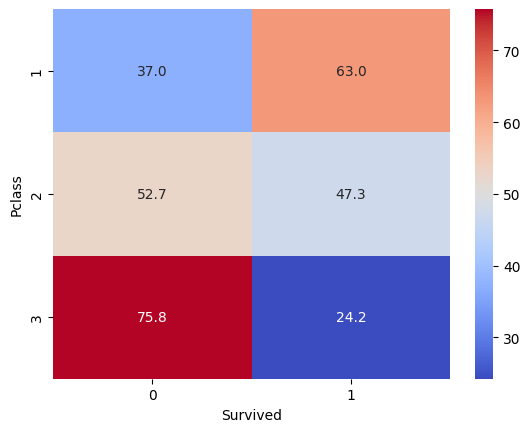

In [21]:
sns.heatmap(
    pd.crosstab(titanic['Pclass'], titanic['Survived'], normalize='index') * 100,
    annot=True,
    fmt='.1f',
    cmap='coolwarm'
)

In [24]:
(titanic.groupby('Embarked')['Survived'].mean() * 100)


Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64

# 6. ClusterMap (Categorical - Categorical)

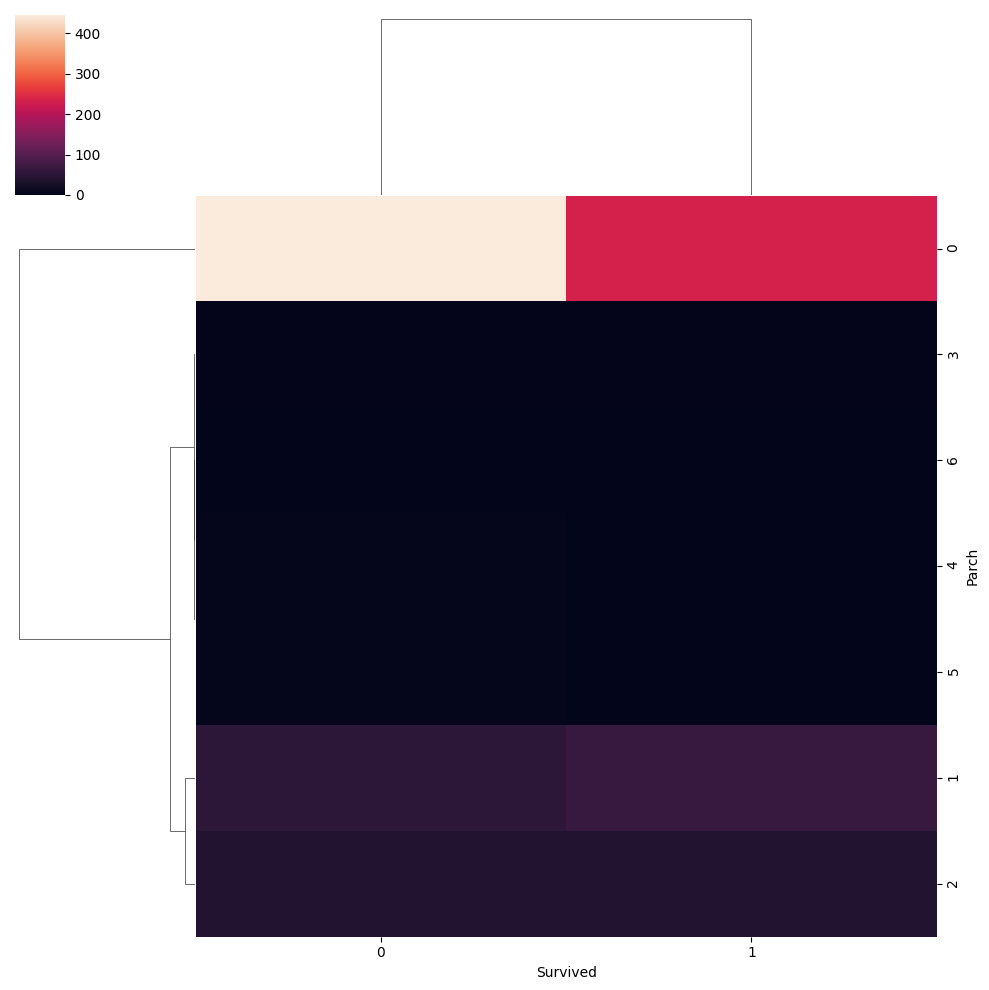

In [23]:
sns.clustermap(pd.crosstab(titanic['Parch'],titanic['Survived']))

# 7. Pairplot

In [25]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


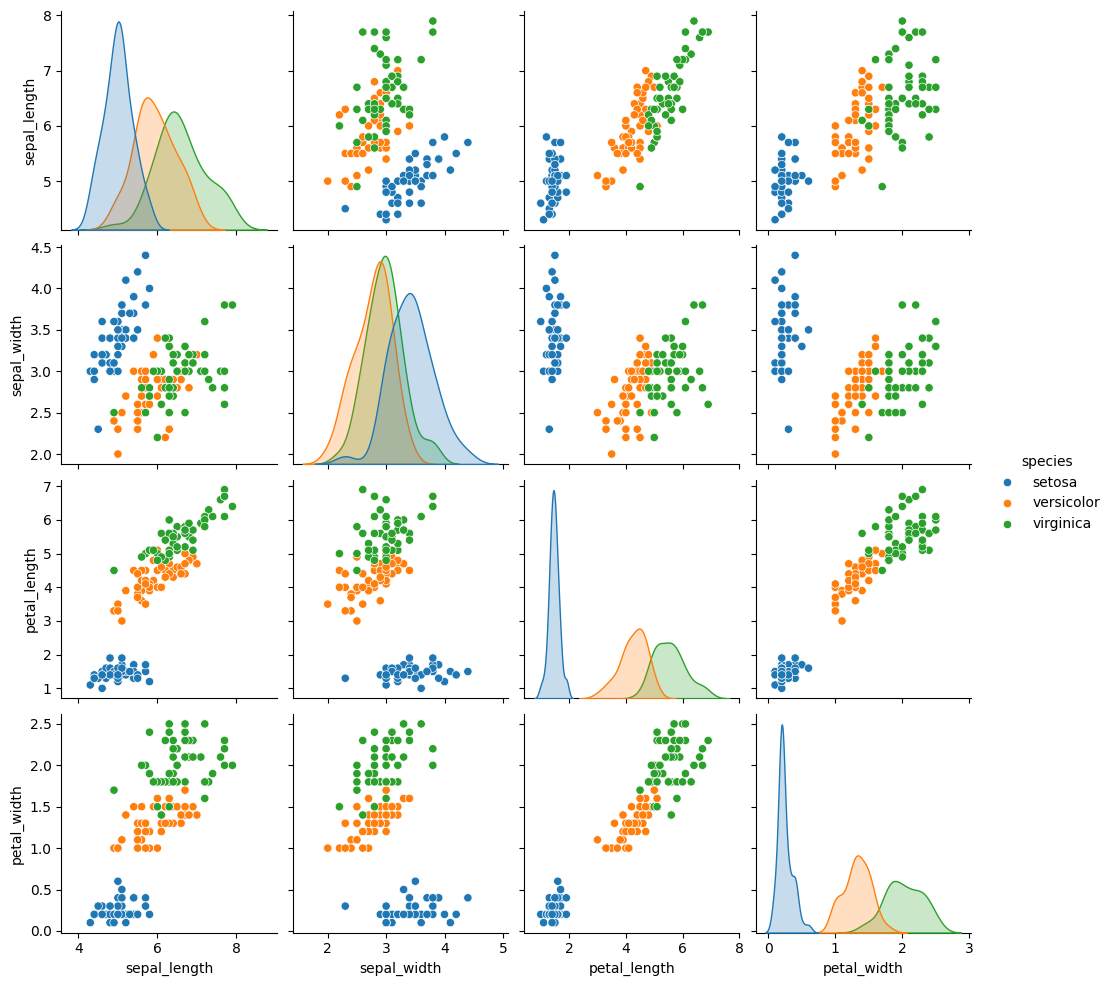

In [26]:
sns.pairplot(iris,hue='species')

# 8. Lineplot (Numerical - Numerical)

In [27]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [29]:
new = flights.groupby('year')['passengers'].sum().reset_index()

<Axes: xlabel='year', ylabel='passengers'>

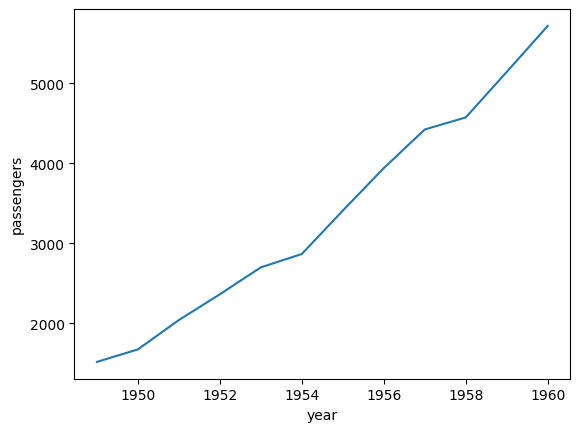

In [31]:
sns.lineplot(data=new,
             x='year',
             y='passengers')

In [32]:
flights

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


C:\Users\prath\AppData\Local\Temp\ipykernel_12868\3937594473.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  flights.pivot_table(values='passengers', index='month', columns='year'),


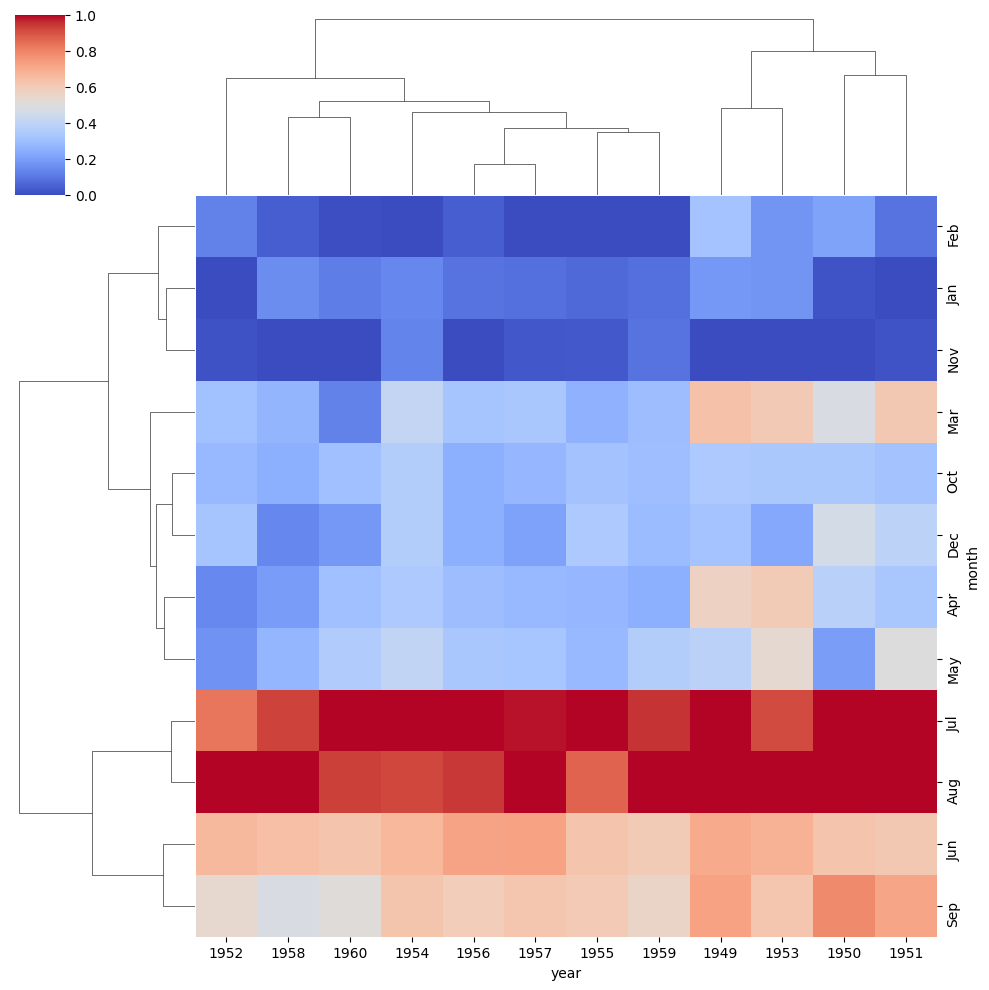

In [34]:
sns.clustermap(
    flights.pivot_table(values='passengers', index='month', columns='year'),
    cmap='coolwarm',
    standard_scale=1
)